# 1. Imports

In [2]:
!pip install scorecardpy

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for scorecardpy: filename=scorecardpy-0.1.9.7-py3-none-any.whl size=60661 sha256=55627b71155e75c8cfc12423afd61b349eed6a7563a773d9fdf4fed4f262103a
  Stored in directory: c:\users\simam\appdata\local\pip\cache\wheels\9f\d8\4e\61a6f4e78fe6700f66b699ab38377f0aa5b33e3ef55751ba38
Successfully built scorecardpy


In [3]:
import pandas as pd
import numpy as np
import scorecardpy as sc
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# 2. Load the data

In [4]:
data = sc.germancredit()

# Convert target
data['creditability'] = data['creditability'].map({'good': 0, 'bad': 1})

data.head()

,status_of_existing_checking_account,duration_in_month,credit_history,purpose,credit_amount,savings_account_and_bonds,present_employment_since,installment_rate_in_percentage_of_disposable_income,personal_status_and_sex,other_debtors_or_guarantors,...,property,age_in_years,other_installment_plans,housing,number_of_existing_credits_at_this_bank,job,number_of_people_being_liable_to_provide_maintenance_for,telephone,foreign_worker,creditability
0,... < 0 DM,6,critical account/ other credits existing (not ...,radio/television,1169,unknown/ no savings account,... >= 7 years,4,male : divorced/separated,none,...,real estate,67,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes,0
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,radio/television,5951,... < 100 DM,1 <= ... < 4 years,2,male : divorced/separated,none,...,real estate,22,none,own,1,skilled employee / official,1,none,yes,1
2,no checking account,12,critical account/ other credits existing (not ...,education,2096,... < 100 DM,4 <= ... < 7 years,2,male : divorced/separated,none,...,real estate,49,none,own,1,unskilled - resident,2,none,yes,0
3,... < 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,... < 100 DM,4 <= ... < 7 years,2,male : divorced/separated,guarantor,...,building society savings agreement/ life insur...,45,none,for free,1,skilled employee / official,2,none,yes,0
4,... < 0 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : divorced/separated,none,...,unknown / no property,53,none,for free,2,skilled employee / official,2,none,yes,1


In [9]:
list(data.columns)

['status_of_existing_checking_account',
 'duration_in_month',
 'credit_history',
 'purpose',
 'credit_amount',
 'savings_account_and_bonds',
 'present_employment_since',
 'installment_rate_in_percentage_of_disposable_income',
 'personal_status_and_sex',
 'other_debtors_or_guarantors',
 'present_residence_since',
 'property',
 'age_in_years',
 'other_installment_plans',
 'housing',
 'number_of_existing_credits_at_this_bank',
 'job',
 'number_of_people_being_liable_to_provide_maintenance_for',
 'telephone',
 'foreign_worker',
 'creditability']

# 3. Train/Test Split

In [5]:
train, test = sc.split_df(data, 'creditability').values()

In [6]:
print(f'Shape of test: {test.shape} and shape of train:{train.shape}')

Shape of test: (300, 21) and shape of train:(700, 21)


# 4. Binning (Core Scorecard Step)

In [11]:
import warnings
warnings.filterwarnings("ignore")
bins = sc.woebin(train, y='creditability')

# View binning for one variable
bins['age_in_years']

[INFO] creating woe binning ...


,variable,bin,count,count_distr,good,bad,badprob,woe,bin_iv,total_iv,breaks,is_special_values
0,age_in_years,"[-inf,26.0)",128,0.182857,74,54,0.421875,0.532217,0.056480,0.152533,26.0,False
1,age_in_years,"[26.0,33.0)",209,0.298571,146,63,0.301435,0.006826,0.000014,0.152533,33.0,False
2,age_in_years,"[33.0,35.0)",47,0.067143,29,18,0.382979,0.370374,0.009826,0.152533,35.0,False
3,age_in_years,"[35.0,37.0)",56,0.080000,49,7,0.125000,-1.098612,0.073241,0.152533,37.0,False
4,age_in_years,"[37.0,inf)",260,0.371429,192,68,0.261538,-0.190690,0.012972,0.152533,inf,False


+ve WOE good risk, low risk/safe
-ve WOE high risk 

IV:

IV Value	Meaning

< 0.02	    Useless

0.02–0.1	Weak

0.1–0.3	    Medium

0.3–0.5	    Strong

.> 0.5	    Suspicious (maybe leakage )


# 5. WOE Transformation

In [16]:
train_woe = sc.woebin_ply(train, bins)
test_woe = sc.woebin_ply(test, bins)

[INFO] converting into woe values ...
[INFO] converting into woe values ...


In [17]:
train_woe.head()

,creditability,savings_account_and_bonds_woe,job_woe,number_of_people_being_liable_to_provide_maintenance_for_woe,credit_history_woe,present_employment_since_woe,purpose_woe,other_installment_plans_woe,property_woe,other_debtors_or_guarantors_woe,...,status_of_existing_checking_account_woe,duration_in_month_woe,personal_status_and_sex_woe,telephone_woe,credit_amount_woe,housing_woe,age_in_years_woe,number_of_existing_credits_at_this_bank_woe,installment_rate_in_percentage_of_disposable_income_woe,foreign_worker_woe
0,0,-0.680310,-0.004353,0.012180,-0.695076,-0.251314,-0.394957,-0.125589,-0.441358,0.017082,...,0.600624,-1.195776,-0.173756,-0.105361,0.122898,-0.196399,-0.190690,-0.204794,0.172333,0.0
2,0,0.281251,-0.168623,-0.062914,-0.695076,-0.360117,0.418843,-0.125589,-0.441358,0.017082,...,-1.199354,-0.031253,-0.173756,0.072321,-0.195225,-0.196399,-0.190690,0.110001,-0.226622,0.0
4,1,0.281251,-0.004353,-0.062914,0.081830,0.083382,0.418843,-0.125589,0.507430,0.017082,...,0.600624,-0.031253,-0.173756,0.072321,0.650588,0.464306,-0.190690,-0.204794,-0.030772,0.0
5,0,-0.680310,-0.168623,-0.062914,0.116724,0.083382,0.418843,-0.125589,0.507430,0.017082,...,-1.199354,0.462886,-0.173756,-0.105361,0.899942,0.464306,-1.098612,0.110001,-0.226622,0.0
6,0,-0.334202,-0.004353,0.012180,0.116724,-0.251314,0.147230,-0.125589,0.108894,0.017082,...,-1.199354,-0.031253,-0.173756,0.072321,-0.195225,-0.196399,-0.190690,0.110001,-0.030772,0.0


# 6. Model Training (PD Model)

In [18]:
X_train = train_woe.drop(columns=['creditability'])
y_train = train_woe['creditability']

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [22]:
X_test = test_woe.drop(columns=['creditability'])
y_test = test_woe['creditability']

pred = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, pred)
print("AUC:", auc)

AUC: 0.7972486772486773


In [20]:
X_train = train_woe.drop(columns=['creditability'])
y_train = train_woe['creditability']

pred = model.predict_proba(X_train)[:, 1]

auc = roc_auc_score(y_train, pred)
print("AUC:", auc)

AUC: 0.8463556851311953


There is consistency in training and testing

# 8. KS + Performance Plot

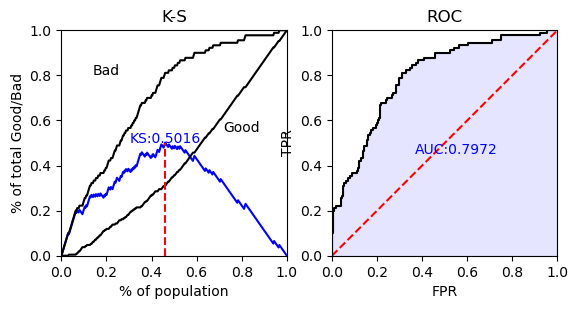

{'KS': 0.5016,
 'AUC': 0.7972,
 'Gini': 0.5945,
 'pic': <Figure size 640x480 with 2 Axes>}

In [23]:
sc.perf_eva(y_test, pred)

|KS Value|	Meaning|

|< 0.2|	Weak model|

|0.2 – 0.4|	Acceptable|

|0.4 – 0.6|	Strong|

|> 0.6|	Very strong (rare)|

# Build scorecard

In [24]:
card = sc.scorecard(bins, model, X_train.columns)

# Apply scorecard
test_score = sc.scorecard_ply(test, card)

test_score.head()

,score
1,413.0
3,329.0
9,429.0
10,317.0
12,484.0


In [25]:
test_score.tail()

,score
979,308.0
987,641.0
991,486.0
993,423.0
994,551.0


In [26]:
test_score.min()

score    183.0
dtype: float64

In [27]:
test_score.max()

score    766.0
dtype: float64

In [28]:
test_score.describe()

,score
count,300.000000
mean,475.710000
std,113.163211
min,183.000000
25%,394.000000
50%,470.500000
75%,554.000000
max,766.000000


In [29]:
card.head()

AttributeError: 'dict' object has no attribute 'head'